<a href="https://colab.research.google.com/github/mahamoorthi22007/AI-Internship/blob/main/NN_on_mnist_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
.import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
mnist=keras.datasets.mnist
(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [ ]:
x_train,x_test=x_train/255,x_test/255

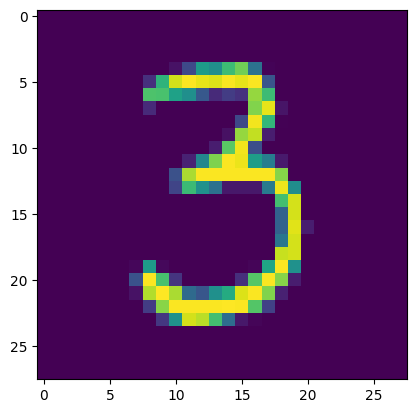

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(x_train[50])

In [ ]:
x_train.shape

(60000, 28, 28)

In [ ]:
model=keras.Sequential([layers.Flatten(input_shape=(28,28,1)),
layers.Dense(128,activation='relu'),layers.Dense(10,activation='sigmoid')])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(x_train,y_train,epochs=20,validation_split=0.1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9216 - loss: 0.2734 - val_accuracy: 0.9687 - val_loss: 0.1213
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9639 - loss: 0.1208 - val_accuracy: 0.9702 - val_loss: 0.0998
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9748 - loss: 0.0844 - val_accuracy: 0.9783 - val_loss: 0.0804
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9813 - loss: 0.0619 - val_accuracy: 0.9767 - val_loss: 0.0828
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9848 - loss: 0.0487 - val_accuracy: 0.9803 - val_loss: 0.0724
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9884 - loss: 0.0375 - val_accuracy: 0.9755 - val_loss: 0.0835
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9907 - loss: 0.0303 - val_accuracy: 0.9800 - val_loss: 0.0780
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9929 - loss: 0.0

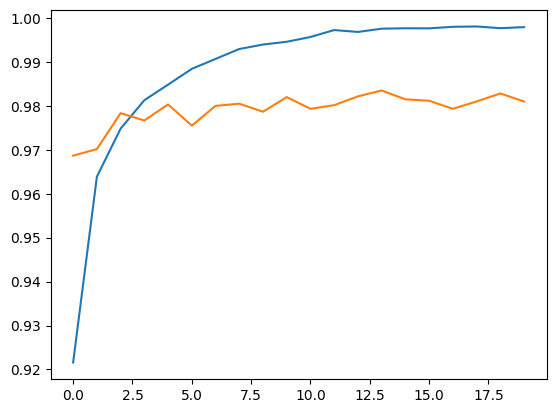

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [ ]:
y_pred=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
y_pred[5000]

array([3.4299741e-09, 2.1041583e-07, 4.8036972e-04, 1.0000000e+00,
       7.8573481e-11, 1.8707270e-02, 2.6538211e-10, 1.8461558e-08,
       7.2559202e-03, 2.8471462e-07], dtype=float32)

In [ ]:
import numpy as np
ans=np.argmax(y_pred,axis=1)
ans[5000]

np.int64(3)

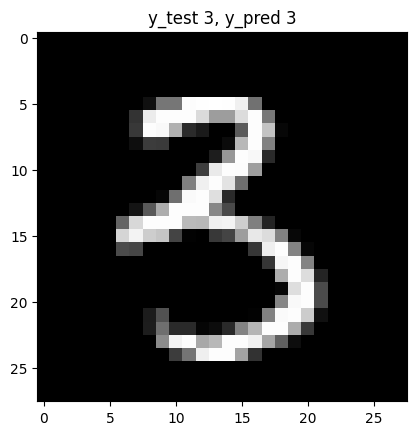

In [ ]:
test=y_test[5000]
pred=ans[5000]
plt.title(f"y_test {test}, y_pred {pred}")
plt.imshow(x_test[5000],cmap='gray')

In [ ]:
import cv2

In [ ]:
img=cv2.imread('/content/7.png',0)

In [ ]:
img = cv2.resize(img, (28, 28))

In [ ]:
new = img / 255.0

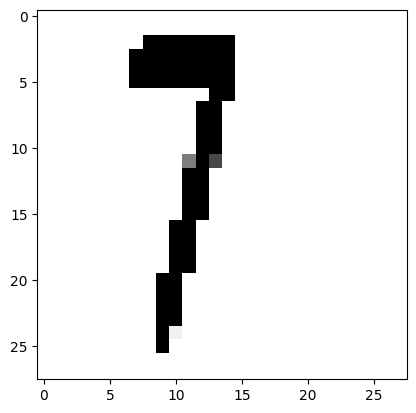

In [ ]:
plt.imshow(new,cmap='gray')

In [ ]:
input_for_prediction = new.reshape(1, 28, 28) # Reshape to (batch_size, height, width)
pred = model.predict(input_for_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


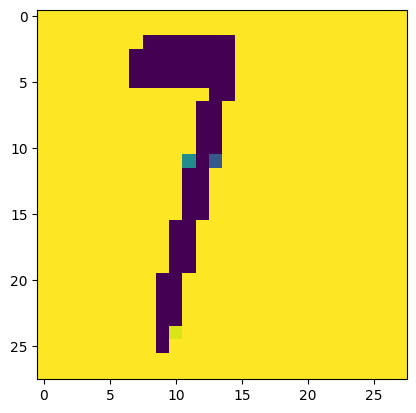

In [ ]:
plt.imshow(input_for_prediction[0])

In [ ]:
ans=np.argmax(pred,axis=1)

In [ ]:
ans

array([7])

In [ ]:
model.save("mnist-model.h5")